# 🌸 Iris Türü Sınıflandırma — Gaussian Naive Bayes

**🇹🇷 Türkçe:**
Bu notebook, klasik **Iris** veri setinde çiçek türünü (`Species`) tahmin etmek için **Gaussian Naive Bayes** sınıflandırıcısını kullanıyor. Veri seti 150 satır ve 3 dengeli sınıf içeriyor: *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*. Akış şu adımlardan oluşuyor: veriyi yükleme → keşifçi veri analizi (EDA) → görselleştirme → etiket kodlama → eğitim/test ayrımı → ölçekleme → model eğitimi → değerlendirme.

**Naive Bayes nedir?** Bayes Teoremi'ne dayanan olasılıksal bir sınıflandırıcıdır. "Naive" (saf) denmesinin sebebi, tüm özelliklerin birbirinden **bağımsız** olduğunu varsaymasıdır — gerçek hayatta bu varsayım genelde tam doğru değildir ama model yine de şaşırtıcı derecede iyi çalışır. `GaussianNB` versiyonu, sayısal özelliklerin her sınıf içinde **normal (Gauss) dağılıma** sahip olduğunu varsayar; bu yüzden Iris gibi sürekli ölçüm içeren veri setlerine çok uygundur.

**🇬🇧 English:**
This notebook uses a **Gaussian Naive Bayes** classifier to predict the flower species (`Species`) on the classic **Iris** dataset. The dataset has 150 rows and 3 balanced classes: *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*. The pipeline is: load data → exploratory data analysis (EDA) → visualization → label encoding → train/test split → scaling → model training → evaluation.

**What is Naive Bayes?** It is a probabilistic classifier based on Bayes' Theorem. It is called "naive" because it assumes all features are **conditionally independent** of each other — an assumption rarely fully true in practice, yet the model still performs surprisingly well. The `GaussianNB` variant assumes each numeric feature follows a **normal (Gaussian) distribution** within each class, which makes it a natural fit for datasets of continuous measurements like Iris.

---

## 📦 Kütüphaneleri İçe Aktarma / Import Libraries

**🇹🇷 Türkçe:**
Veri işleme için `pandas` ve `numpy`, görselleştirme için `matplotlib` ve `seaborn` yükleniyor. `%matplotlib inline` grafiklerin notebook içinde gösterilmesini sağlıyor.

**🇬🇧 English:**
`pandas` and `numpy` are imported for data handling, `matplotlib` and `seaborn` for visualization. `%matplotlib inline` makes plots render inside the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Iris veri seti CSV dosyasından okunuyor. Aşağıdaki hücre hem Kaggle ortamında (`/kaggle/input/iris/Iris.csv`) hem de yerel repo yapısında (`../../Data/11-iris.csv`) çalışacak şekilde yolu otomatik seçiyor.

**🇬🇧 English:**
The Iris dataset is read from a CSV file. The cell below automatically picks the right path so it works both on Kaggle (`/kaggle/input/iris/Iris.csv`) and in the local repository layout (`../../Data/11-iris.csv`).

In [2]:
import os, glob

# Kaggle'da veri seti /kaggle/input altina baglanir; yerelde repo icindeki CSV kullanilir.
# On Kaggle the dataset is mounted under /kaggle/input; locally the repo CSV is used.
matches = glob.glob('/kaggle/input/**/Iris*.csv', recursive=True)
if not matches:
    for root, dirs, files in os.walk('/kaggle/input'):
        print(root, files)
path = matches[0] if matches else '../../Data/11-iris.csv'
print('Reading:', path)
df = pd.read_csv(path)


## 🔍 2. Veriyi Tanıma / Exploring the Data

**🇹🇷 Türkçe:**
Modelleme öncesi veriyi tanımak şart. `head()` ilk satırları, `describe()` sayısal kolonların özet istatistiklerini (ortalama, standart sapma, min/max), `isnull().sum()` ise eksik değer sayısını gösteriyor. Son olarak `value_counts()` ile sınıf dağılımına bakıyoruz — Iris veri seti **dengeli**dir, her türden 50 örnek vardır. Bu, doğruluk (accuracy) metriğinin burada güvenilir bir ölçü olduğu anlamına gelir.

**🇬🇧 English:**
Understanding the data before modelling is essential. `head()` shows the first rows, `describe()` gives summary statistics of the numeric columns (mean, standard deviation, min/max), and `isnull().sum()` reports missing values. Finally, `value_counts()` shows the class distribution — the Iris dataset is **balanced**, with 50 samples per species. That means accuracy is a trustworthy metric here.

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [8]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 🧹 3. Gereksiz Kolonu Kaldırma / Dropping a Useless Column

**🇹🇷 Türkçe:**
`Id` kolonu sadece bir satır numarasıdır; çiçeğin türü hakkında hiçbir bilgi taşımaz. Modele verilirse gürültü (noise) yaratır, bu yüzden kaldırılıyor.

**🇬🇧 English:**
The `Id` column is just a row number and carries no information about the species. Feeding it to the model would only add noise, so it is dropped.

In [14]:
df = df.drop("Id", axis=1)

## 📊 4. Görselleştirme / Visualization — Pairplot

**🇹🇷 Türkçe:**
`sns.pairplot`, tüm özellik çiftlerinin saçılım grafiklerini ve köşegende her özelliğin dağılımını çiziyor; `hue="Species"` sayesinde her tür farklı renkte görünüyor. Grafiklerden iki önemli çıkarım yapabiliriz:
1. **Iris-setosa** diğer iki türden tamamen ayrışıyor (özellikle `PetalLengthCm` ve `PetalWidthCm` ile) — yani doğrusal olarak kolayca ayrılabilir.
2. *versicolor* ve *virginica* kısmen üst üste biniyor; modelin hata yapacağı yer varsa burasıdır.

Ayrıca köşegendeki dağılımların sınıf bazında yaklaşık **çan eğrisi** şeklinde olması, Gaussian Naive Bayes'in normal dağılım varsayımının bu veri için makul olduğunu gösteriyor.

**🇬🇧 English:**
`sns.pairplot` draws scatter plots for every pair of features, with each feature's distribution on the diagonal; `hue="Species"` colours each species differently. Two key takeaways:
1. **Iris-setosa** is completely separated from the other two species (especially by `PetalLengthCm` and `PetalWidthCm`) — it is trivially linearly separable.
2. *versicolor* and *virginica* partially overlap; if the model makes mistakes, it will be here.

Also, the per-class distributions on the diagonal are roughly **bell-shaped**, which supports the normality assumption behind Gaussian Naive Bayes for this dataset.

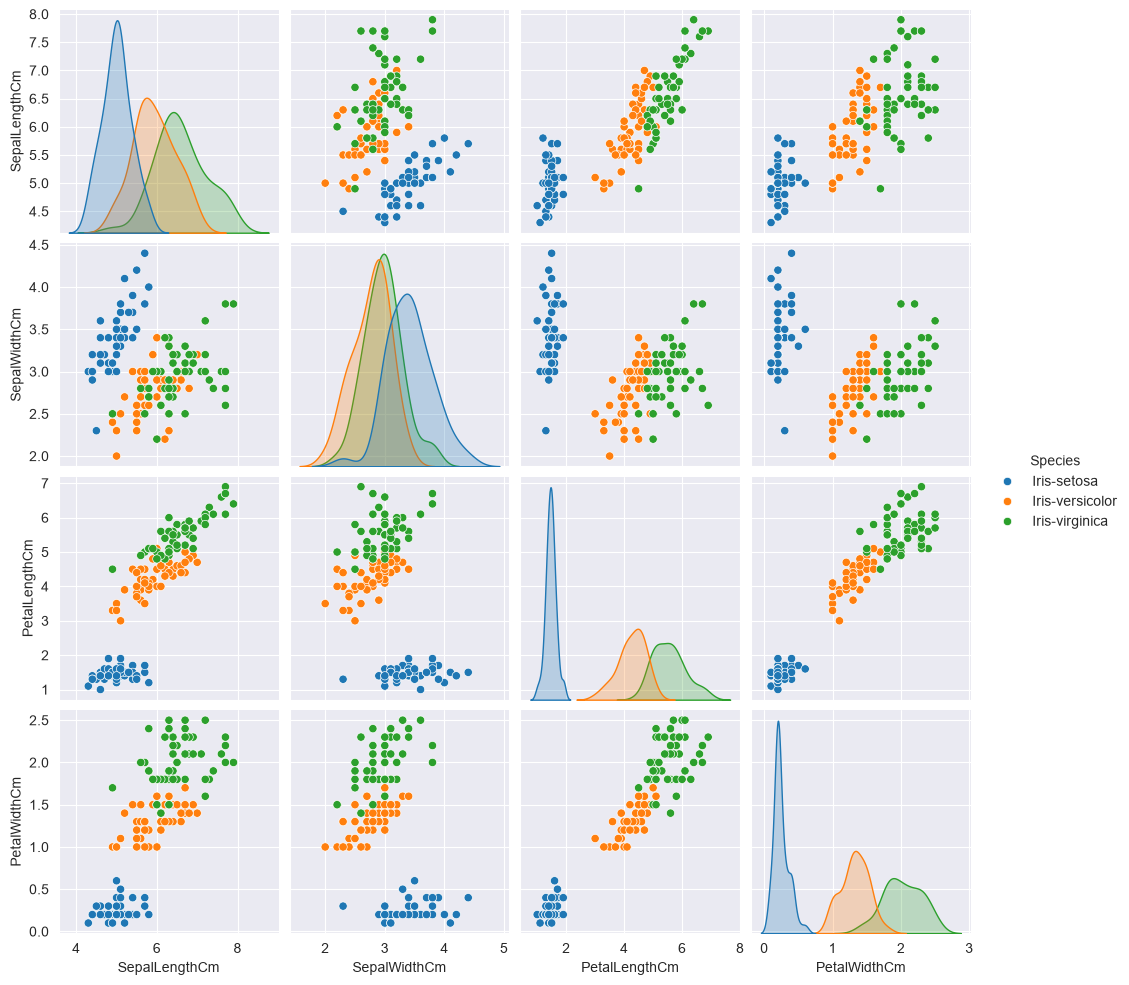

In [15]:
sns.pairplot(df,hue="Species")
plt.show()

## 🔤 5. Hedef Değişkeni Kodlama / Encoding the Target — LabelEncoder

**🇹🇷 Türkçe:**
`Species` kolonu metin ("Iris-setosa" gibi) içerdiği için, scikit-learn'ün anlayabileceği sayısal etiketlere dönüştürülmesi gerekiyor. `LabelEncoder` her sınıfa bir tamsayı atıyor: 0 = setosa, 1 = versicolor, 2 = virginica. Dönüşümün ardından `value_counts()` ile hâlâ 50-50-50 dengesinin korunduğunu doğruluyoruz.

> ℹ️ `LabelEncoder` **hedef değişken** için uygundur. Girdi (feature) tarafındaki kategorik kolonlarda kullanılırsa modele yanlışlıkla sıralama (0 < 1 < 2) bilgisi verir; orada `OneHotEncoder` tercih edilmelidir.

**🇬🇧 English:**
The `Species` column holds text values (e.g. "Iris-setosa"), so it must be converted into numeric labels that scikit-learn can work with. `LabelEncoder` assigns an integer to each class: 0 = setosa, 1 = versicolor, 2 = virginica. After the transformation, `value_counts()` confirms the 50-50-50 balance is preserved.

> ℹ️ `LabelEncoder` is meant for the **target** variable. Using it on categorical *input* features would falsely imply an ordering (0 < 1 < 2); `OneHotEncoder` is the right tool there.

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
labelencoder = LabelEncoder()

In [18]:
df["Species"] = labelencoder.fit_transform(df["Species"])

In [19]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

## ✂️ 6. Özellikler ve Hedef / Features and Target

**🇹🇷 Türkçe:**
`X` bağımsız değişkenleri (4 ölçüm: sepal uzunluk/genişlik, petal uzunluk/genişlik), `y` ise tahmin etmeye çalıştığımız hedefi (`Species`) tutuyor.

**🇬🇧 English:**
`X` holds the independent variables (the 4 measurements: sepal length/width, petal length/width) and `y` holds the target we are trying to predict (`Species`).

In [20]:
X = df.drop("Species", axis=1)

In [21]:
y = df["Species"]

## 🔀 7. Eğitim / Test Ayrımı / Train-Test Split

**🇹🇷 Türkçe:**
Veri %80 eğitim, %20 test olacak şekilde ayrılıyor (`test_size=0.2` → 120 eğitim, 30 test satırı). `random_state=15` ayrımın her çalıştırmada aynı olmasını sağlar, böylece sonuçlar tekrarlanabilir olur. Modeli hiç görmediği veriyle test etmek, ezberleyip ezberlemediğini (overfitting) anlamamızın tek yoludur.

> 💡 Küçük ve dengeli bir veri setinde `stratify=y` parametresini eklemek, test kümesinde de sınıf oranlarının korunmasını garantiler.

**🇬🇧 English:**
The data is split into 80% training and 20% test (`test_size=0.2` → 120 train and 30 test rows). `random_state=15` makes the split reproducible across runs. Evaluating on data the model has never seen is the only way to detect overfitting.

> 💡 On a small, balanced dataset, adding `stratify=y` guarantees the class proportions are preserved in the test set as well.

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)

## ⚖️ 8. Özellik Ölçekleme / Feature Scaling

**🇹🇷 Türkçe:**
`StandardScaler` her özelliği ortalaması 0, standart sapması 1 olacak şekilde standartlaştırıyor. Dikkat edilmesi gereken en kritik nokta: `fit_transform` **sadece eğitim** verisine, `transform` ise test verisine uygulanır. Aksi halde test verisinin istatistikleri modele sızar (*data leakage*).

> ℹ️ **Not:** Gaussian Naive Bayes her özelliğin ortalamasını ve varyansını sınıf bazında ayrı ayrı tahmin ettiği için ölçeklemeye aslında **ihtiyaç duymaz**; burada ölçeklemek sonucu değiştirmez. Yine de KNN, SVM, lojistik regresyon gibi mesafe/gradyan temelli modellerde ölçekleme zorunludur, bu yüzden alışkanlık olarak öğrenmek faydalıdır.

**🇬🇧 English:**
`StandardScaler` standardizes each feature to zero mean and unit variance. The critical detail: `fit_transform` is applied **only to the training set**, while the test set is only `transform`ed. Otherwise statistics from the test set leak into the model (*data leakage*).

> ℹ️ **Note:** Gaussian Naive Bayes estimates the mean and variance of each feature per class on its own, so it does **not** actually require scaling — it will not change the result here. Scaling is still mandatory for distance- or gradient-based models such as KNN, SVM and logistic regression, so it is a good habit to practise.

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🤖 9. Modeli Eğitme / Training the Model — GaussianNB

**🇹🇷 Türkçe:**
`GaussianNB` modeli oluşturulup `fit()` ile eğitim verisine uyduruluyor. Eğitim sırasında model, her sınıf için her özelliğin **ortalamasını ve varyansını** hesaplar; ayrıca sınıfların ön (prior) olasılıklarını öğrenir. Tahmin sırasında Bayes Teoremi ile en yüksek sonsal (posterior) olasılığa sahip sınıfı seçer. Eğitilecek bir hiperparametre neredeyse yoktur, bu yüzden çok hızlı çalışır.

**🇬🇧 English:**
A `GaussianNB` model is created and fitted to the training data with `fit()`. During training, the model computes the **mean and variance** of every feature for each class, plus the class prior probabilities. At prediction time it applies Bayes' Theorem and picks the class with the highest posterior probability. There are virtually no hyperparameters to tune, which is why it trains almost instantly.

In [27]:
from sklearn.naive_bayes import GaussianNB

In [28]:
gaussian_nb = GaussianNB()

In [29]:
gaussian_nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[42.,37.,41.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.35,0.31,0.34]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[-1. , 0.82,-1.27,-1.23], [ 0.18,-0.65, 0.33, 0.2 ], [ 0.87,-0.25, 1.01, 1.07]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.18,0.74,0.01,0.02], [0.37,0.57,0.06,0.07], [0.61,0.51,0.09,0.12]]"


## 🔮 10. Tahmin / Making Predictions

**🇹🇷 Türkçe:**
Eğitilen model, daha önce hiç görmediği test verisi üzerinde tahmin yapıyor. `y_pred` dizisi her test örneği için tahmin edilen sınıf etiketini (0, 1 veya 2) içeriyor.

**🇬🇧 English:**
The trained model makes predictions on the unseen test data. The `y_pred` array contains the predicted class label (0, 1, or 2) for each test sample.

In [30]:
y_pred = gaussian_nb.predict(X_test)

## 📈 11. Model Değerlendirme / Model Evaluation

**🇹🇷 Türkçe:**
**Karışıklık matrisi (confusion matrix)** satırlarda gerçek sınıfları, sütunlarda tahmin edilen sınıfları gösterir. Köşegen üzerindeki değerler doğru tahminlerdir; köşegen dışındaki her sayı bir hatadır. **Doğruluk (accuracy)** ise doğru tahminlerin toplam örneğe oranıdır.

Sonuç: köşegen dışı tüm değerler **0** ve doğruluk **1.00 (%100)** — modelin 30 test örneğinin tamamını doğru sınıflandırdığı anlamına geliyor.

**🇬🇧 English:**
The **confusion matrix** shows the true classes on the rows and the predicted classes on the columns. Values on the diagonal are correct predictions; every off-diagonal number is an error. **Accuracy** is the ratio of correct predictions to the total number of samples.

Result: all off-diagonal values are **0** and accuracy is **1.00 (100%)** — the model classified all 30 test samples correctly.

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [32]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[ 8  0  0]
 [ 0 13  0]
 [ 0  0  9]]
1.0


## 🏁 Sonuç / Conclusion

**🇹🇷 Türkçe:**
Gaussian Naive Bayes, Iris veri setinde test kümesinde **%100 doğruluk** elde etti. Bunun sebepleri:
- Iris çok küçük, temiz ve dengeli bir veri seti; sınıflar (özellikle petal ölçümleriyle) neredeyse tamamen ayrışıyor.
- Özelliklerin sınıf içi dağılımları normale yakın olduğu için `GaussianNB`'nin varsayımı sağlanıyor.
- Test kümesi sadece 30 satır; bu kadar küçük bir kümede %100 sonucunu **temkinli** yorumlamak gerekir.

Daha sağlam bir değerlendirme için sonraki adımlar: `cross_val_score` ile **k-katlı çapraz doğrulama**, `classification_report` ile sınıf bazında precision/recall/F1 değerleri ve farklı `random_state` değerleriyle sonucun kararlılığını sınamak.

**🇬🇧 English:**
Gaussian Naive Bayes achieved **100% accuracy** on the Iris test set. The reasons:
- Iris is a very small, clean and balanced dataset whose classes are almost perfectly separable (especially by the petal measurements).
- The per-class feature distributions are close to normal, so the `GaussianNB` assumption holds.
- The test set is only 30 rows, so a 100% score on such a small sample should be interpreted **cautiously**.

Sensible next steps for a more robust evaluation: **k-fold cross-validation** via `cross_val_score`, per-class precision/recall/F1 via `classification_report`, and re-running with different `random_state` values to check the stability of the result.